In [18]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [19]:
# =========================
# 4) 메인 시뮬레이션 (필터/동기/등화 포함)
# =========================
rng = np.random.default_rng(42)

# --- 파라미터
N_bits = 20000
sps = 8
beta = 0.35
span = 10
snr_db = 14

# impairments(일부러 넣음)
frac_delay = 2.3             # 샘플 단위 fractional timing offset
cfo_hz = 0.01                # "심볼레이트 기준" 작은 CFO 느낌(단순화)
phase0 = 0.7                 # 초기 위상 오프셋
multipath = np.array([0.9, 0.25+0.15j, 0.10], dtype=np.complex128)
multipath = multipath / np.linalg.norm(multipath)

In [20]:
# --- TX: bits -> QPSK
def bits_to_qpsk_symbols(bits):
    """0->+1, 1->-1 매핑 기반 QPSK (unit power)"""
    assert len(bits) % 2 == 0
    b0 = bits[0::2]
    b1 = bits[1::2]
    I = np.where(b0 == 0, 1.0, -1.0)
    Q = np.where(b1 == 0, 1.0, -1.0)
    return (I + 1j * Q) / np.sqrt(2)

bits = rng.integers(0, 2, size=N_bits, dtype=np.int8)
if len(bits) % 2 == 1:
  bits = bits[:-1]
syms = bits_to_qpsk_symbols(bits)                                     ## [TX] 01_TX bit generation + Modulation

In [21]:
# --- TX: RRC pulse shaping
def rrc_filter(beta, span, sps):
    """
    Root-Raised-Cosine (RRC) FIR
    beta: roll-off (0~1)
    span: 필터 길이(심볼 단위) 예: 10 -> 총 탭 수는 span*sps+1
    """
    N = span * sps
    t = np.arange(-N/2, N/2 + 1) / sps  # 심볼 단위 시간
    h = np.zeros_like(t, dtype=np.float64)

    for i, ti in enumerate(t):
        if np.isclose(ti, 0.0):
            h[i] = 1.0 - beta + (4*beta/np.pi)
        elif beta != 0 and np.isclose(abs(ti), 1/(4*beta)):
            # 특이점 처리
            h[i] = (beta/np.sqrt(2)) * (
                (1 + 2/np.pi) * np.sin(np.pi/(4*beta))
                + (1 - 2/np.pi) * np.cos(np.pi/(4*beta))
            )
        else:
            num = np.sin(np.pi*ti*(1 - beta)) + 4*beta*ti*np.cos(np.pi*ti*(1 + beta))
            den = np.pi*ti*(1 - (4*beta*ti)**2)
            h[i] = num / den

    # 에너지 정규화(대략)
    h = h / np.sqrt(np.sum(h**2))
    return h

def upsample_zeros(symbols, sps):
    """심볼레이트 -> 샘플레이트 (0 삽입 업샘플링)"""
    x = np.zeros(len(symbols) * sps, dtype=np.complex128)
    x[::sps] = symbols
    return x


h_rrc = rrc_filter(beta, span, sps)                                   ## [TX] 02_RRC Filter (Root Raised Cosine): symbol(점)을 실제 전송가능한 부드러운 시간파형으로 생성
                                                                        ## Purpose: ISI(심볼 간 간섭)를 제어하기 위해 쓰는 표준 펄스 성형 (Pulse shaping) 필터
tx_up = upsample_zeros(syms, sps)                                     ## [TX] 03_

tx = np.convolve(tx_up, h_rrc, mode="same")                           ## [TX] 04_

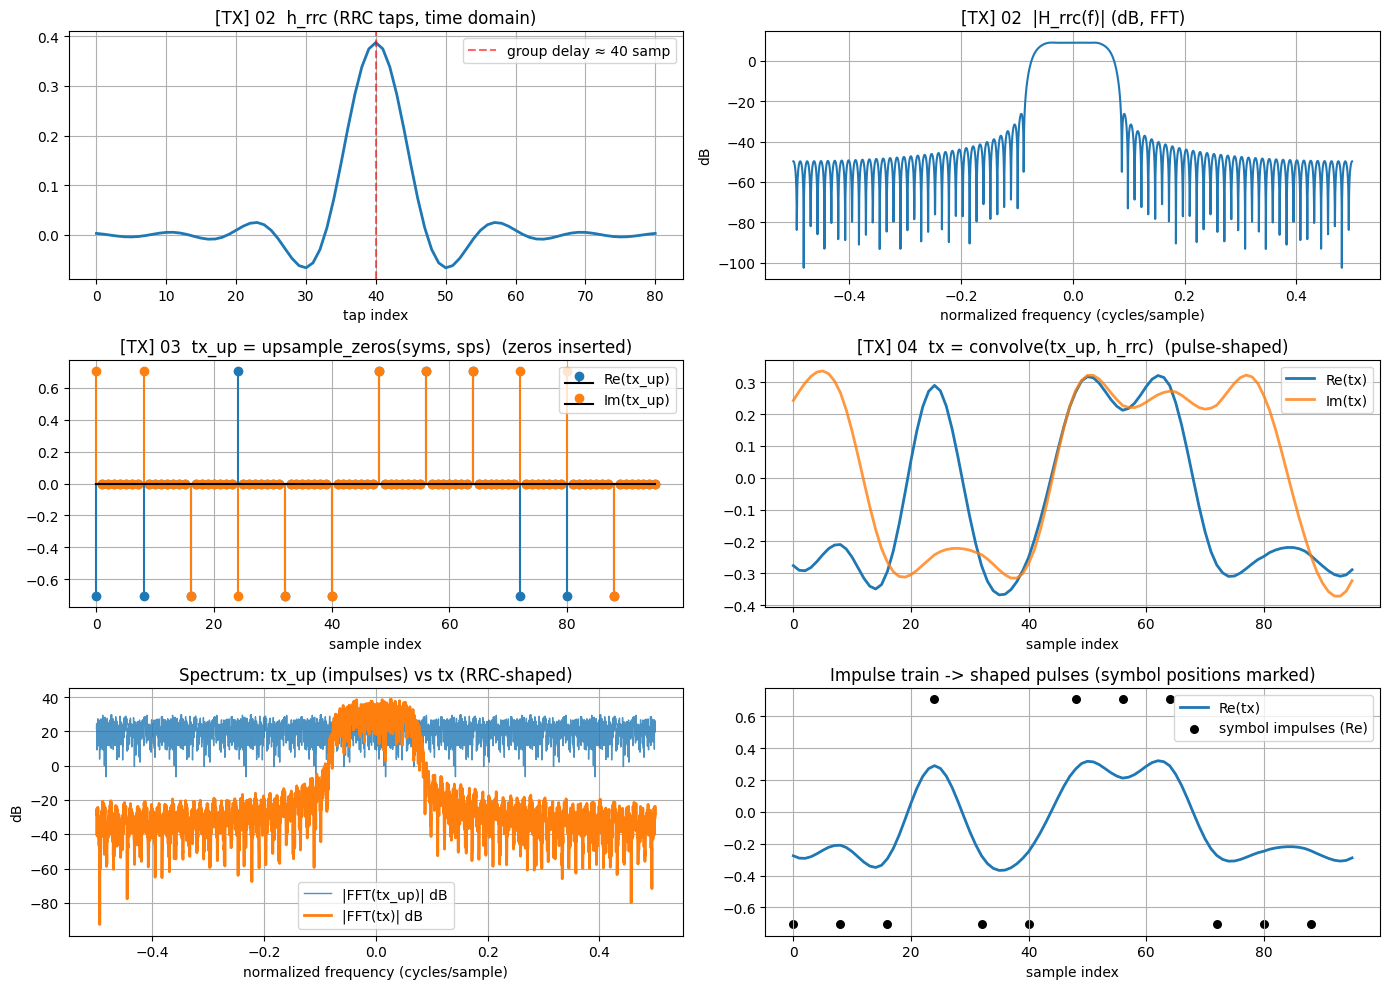

In [22]:
# =========================
# [TX] 02~04 도식화 (h_rrc, tx_up, tx)
# =========================

# 보여줄 심볼/샘플 개수 (너무 크면 그림이 무거움)
n_show_syms = 12
N_show = min(len(tx), n_show_syms * sps)
n = np.arange(N_show)

# (1) RRC 탭/주파수 응답
gd = (len(h_rrc) - 1) // 2  # group delay (samples) for symmetric FIR
Nfft = 4096

H = np.fft.fftshift(np.fft.fft(h_rrc, Nfft))
f = np.fft.fftshift(np.fft.fftfreq(Nfft, d=1.0))  # normalized freq (cycles/sample)
H_mag = 20 * np.log10(np.abs(H) + 1e-12)

# (2) tx_up vs tx 스펙트럼 비교 (같은 길이로 잘라 FFT)
Lfft = min(len(tx), Nfft)
win = np.hanning(Lfft)

Xup = np.fft.fftshift(np.fft.fft(tx_up[:Lfft] * win, Nfft))
Xtx = np.fft.fftshift(np.fft.fft(tx[:Lfft] * win, Nfft))
Xup_mag = 20 * np.log10(np.abs(Xup) + 1e-12)
Xtx_mag = 20 * np.log10(np.abs(Xtx) + 1e-12)

plt.figure(figsize=(14, 10))

# A) h_rrc 시간영역 탭                                                    ## h_rrc visualization
ax1 = plt.subplot(3, 2, 1)
ax1.plot(h_rrc, linewidth=2)
ax1.axvline(gd, color="r", linestyle="--", alpha=0.6, label=f"group delay ≈ {gd} samp")
ax1.set_title("[TX] 02  h_rrc (RRC taps, time domain)")
ax1.set_xlabel("tap index")
ax1.grid(True)
ax1.legend()

# B) h_rrc 주파수 응답                                                    ## frequency responce of h_rrc
ax2 = plt.subplot(3, 2, 2)
ax2.plot(f, H_mag, linewidth=1.5)
ax2.set_title("[TX] 02  |H_rrc(f)| (dB, FFT)")
ax2.set_xlabel("normalized frequency (cycles/sample)")
ax2.set_ylabel("dB")
ax2.grid(True)

# C) tx_up (0 삽입 업샘플링 결과) - stem으로 보면 제일 직관적                   ## tx_upsampled
ax3 = plt.subplot(3, 2, 3)
ax3.stem(n, np.real(tx_up[:N_show]), linefmt="C0-", markerfmt="C0o", basefmt="k-", label="Re(tx_up)")
ax3.stem(n, np.imag(tx_up[:N_show]), linefmt="C1-", markerfmt="C1o", basefmt="k-", label="Im(tx_up)")
ax3.set_title("[TX] 03  tx_up = upsample_zeros(syms, sps)  (zeros inserted)")
ax3.set_xlabel("sample index")
ax3.grid(True)
ax3.legend(loc="upper right")

# D) tx (RRC 컨볼루션 후) - 부드러운 파형으로 퍼짐                            ## After convolution
ax4 = plt.subplot(3, 2, 4)
ax4.plot(n, np.real(tx[:N_show]), linewidth=2, label="Re(tx)")
ax4.plot(n, np.imag(tx[:N_show]), linewidth=2, alpha=0.8, label="Im(tx)")
ax4.set_title("[TX] 04  tx = convolve(tx_up, h_rrc)  (pulse-shaped)")
ax4.set_xlabel("sample index")
ax4.grid(True)
ax4.legend(loc="upper right")

# E) tx_up vs tx 스펙트럼 비교
ax5 = plt.subplot(3, 2, 5)
ax5.plot(f, Xup_mag, linewidth=1, alpha=0.8, label="|FFT(tx_up)| dB")
ax5.plot(f, Xtx_mag, linewidth=2, label="|FFT(tx)| dB")
ax5.set_title("Spectrum: tx_up (impulses) vs tx (RRC-shaped)")
ax5.set_xlabel("normalized frequency (cycles/sample)")
ax5.set_ylabel("dB")
ax5.grid(True)
ax5.legend()

# F) 심볼 위치 표시해서 “임펄스 → 펄스” 감각 주기
ax6 = plt.subplot(3, 2, 6)
ax6.plot(n, np.real(tx[:N_show]), linewidth=2, label="Re(tx)")
sym_idx = np.arange(0, N_show, sps)
ax6.scatter(sym_idx, np.real(tx_up[:N_show][sym_idx]), color="k", s=30, label="symbol impulses (Re)")
ax6.set_title("Impulse train -> shaped pulses (symbol positions marked)")
ax6.set_xlabel("sample index")
ax6.grid(True)
ax6.legend(loc="upper right")

plt.tight_layout()
plt.show()


In [23]:
# --- Channel: multipath
print("multipath: ", multipath)
print("len(multipath): ", len(multipath))

ch = np.convolve(tx, multipath, mode="same")

multipath:  [0.946059  +0.j        0.26279417+0.1576765j 0.10511767+0.j       ]
len(multipath):  3


In [24]:
# --- Channel: timing offset (fractional delay)
def fractional_delay(x, d):
    """
    아주 단순한 fractional delay: 선형 보간으로 d(샘플)만큼 지연
    d가 정수가 아니어도 됨. (스터디용)
    """
    n = np.arange(len(x))
    t = n - d
    # 복소는 실수/허수 따로 보간
    xr = np.interp(t, n, np.real(x), left=0.0, right=0.0)
    xi = np.interp(t, n, np.imag(x), left=0.0, right=0.0)
    return xr + 1j*xi

ch = fractional_delay(ch, frac_delay)

In [25]:
# --- Channel: CFO + phase offset (아주 단순 모델)    ## if(TX_Freq == RX_Freq)  CFO <= 0
n = np.arange(len(ch))
# 여기서 "cfo_hz"는 샘플레이트 기준이 아니라 데모용으로 작게 준 값
# exp(j*2pi*cfo*n/sps)로 심볼당 위상 회전 느낌만 넣는 형태
ch = ch * np.exp(1j*(2*np.pi*cfo_hz*n/sps + phase0))

In [26]:
# --- Channel: AWGN
def add_awgn(x, snr_db, rng):
    """샘플 기준 SNR로 복소 AWGN 추가"""
    sig_power = np.mean(np.abs(x)**2)
    snr_lin = 10**(snr_db/10)
    noise_power = sig_power / snr_lin
    sigma = np.sqrt(noise_power/2)
    n = rng.normal(0, sigma, size=x.shape) + 1j*rng.normal(0, sigma, size=x.shape)
    return x + n

rx = add_awgn(ch, snr_db, rng=rng)

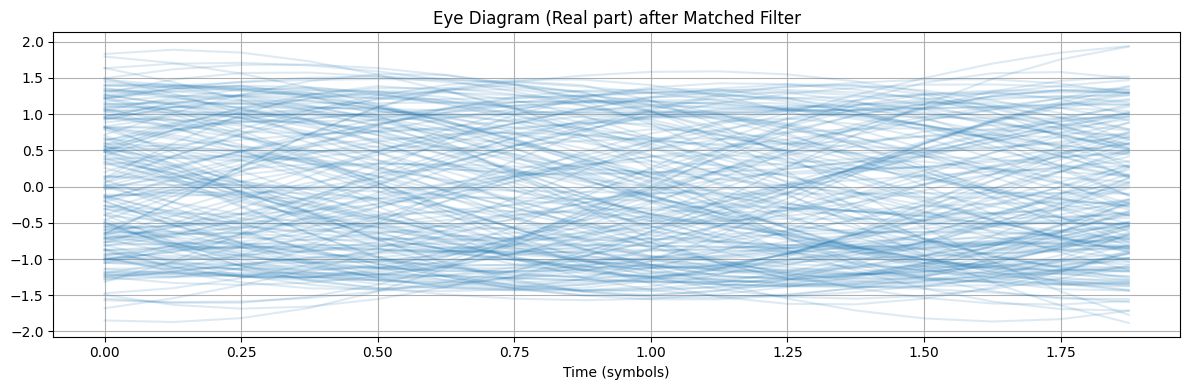

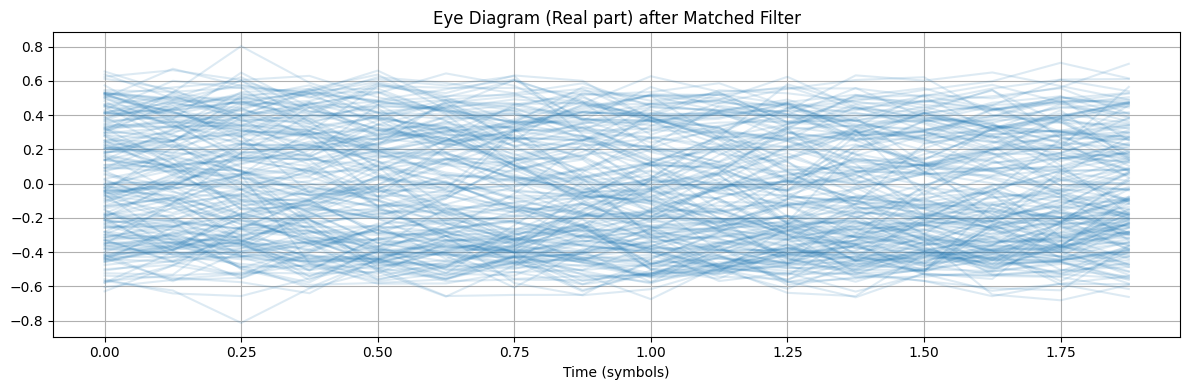

In [27]:
## RX: 필터로 SNR을 모으고, 타이밍을 맞추고, 캐리어 회전을 잡고, 멀티패스를 등화하고, 심볼을 결정해 비트로 복원
##

# --- RX: matched filter (RRC)                                             ## [RX] 01_Matched Filter
rxf = np.convolve(rx, h_rrc, mode="same")
# print(rxf)

# =========================
# Visualization
# =========================
# 1) 매치드필터 출력의 아이 다이어그램(실수부)
# (간단히 2심볼 폭으로 겹치기)
L = 2*sps
ntr = 200
starts = np.linspace(0, len(rxf)-L-1, ntr, dtype=int)             ## if(ntr==200) starts  = [0, 401, 803, 1205, 1607, 2009, 2411, ]
t_eye = np.arange(L)/sps                                          ## if(L==16)    t_eye   = [0., 0.125, 0.25, 0.375, 0.5, 0.625, 0.75, ... ,1.875]

plt.figure(figsize=(12, 4))
for s in starts:
    plt.plot(t_eye, np.real(rxf[s:s+L]), color="C0", alpha=0.15)  ## start from 0 to 16 , from 401 to 417
plt.title("Eye Diagram (Real part) after Matched Filter")
plt.xlabel("Time (symbols)")
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 4))
for s in starts:
    plt.plot(t_eye, np.real(rx[s:s+L]), color="C0", alpha=0.15)  ## start from 0 to 16 , from 401 to 417
plt.title("Eye Diagram (Real part) after Matched Filter")
plt.xlabel("Time (symbols)")
plt.grid(True)
plt.tight_layout()
plt.show()



In [28]:
# # ---- Eye Diagram (aligned to symbol clock) ----
# L = 2*sps
# ntr = 200

# gd = (len(h_rrc)-1)//2              # RRC group delay (samples)
# start0 = gd + (sps//2)              # 대충 심볼 중앙 근처를 찍는 오프셋(데모용)

# # 심볼 경계에 맞춰 시작점 생성: start0, start0+sps, start0+2*sps, ...
# max_start = len(rxf) - L - 1
# starts = start0 + np.arange(ntr) * sps
# starts = starts[starts < max_start]

# t_eye = np.arange(L)/sps

# plt.figure(figsize=(12,4))
# for s in starts:
#     plt.plot(t_eye, np.real(rxf[s:s+L]), color="C0", alpha=0.15)
# plt.title("Eye Diagram (Real part) after Matched Filter (symbol-aligned)")
# plt.xlabel("Time (symbols)")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

Streaming output truncated to the last 5000 lines.
omega: 8.000052348243589
mu: 8.668322268181752
step: 8


mid:    75545.66832226817
early:  75541.66829609405
late:   75549.6683484423
e: 0.8574789461798032
omega: 8.000053205722535
mu: 8.685525052827884
step: 8


mid:    75553.68552505283
early:  75549.68549844997
late:   75557.6855516557
e: 0.1834926393609546
omega: 8.000053389215175
mu: 8.689248294830278
step: 8


mid:    75561.68924829483
early:  75557.68922160023
late:   75565.68927498943
e: 0.9285436385859884
omega: 8.000054317758813
mu: 8.707873485360812
step: 8


mid:    75569.70787348536
early:  75565.70784632648
late:   75573.70790064424
e: -0.795644968683588
omega: 8.000053522113845
mu: 8.692014108100985
step: 8


mid:    75577.6920141081
early:  75573.69198734705
late:   75581.69204086917
e: -0.7787697216103239
omega: 8.000052743344122
mu: 8.6764914570129
step: 8


mid:    75585.67649145701
early:  75581.67646508533
late:   75589.67651782869
e: 0.12763444160889137
omega: 8.0

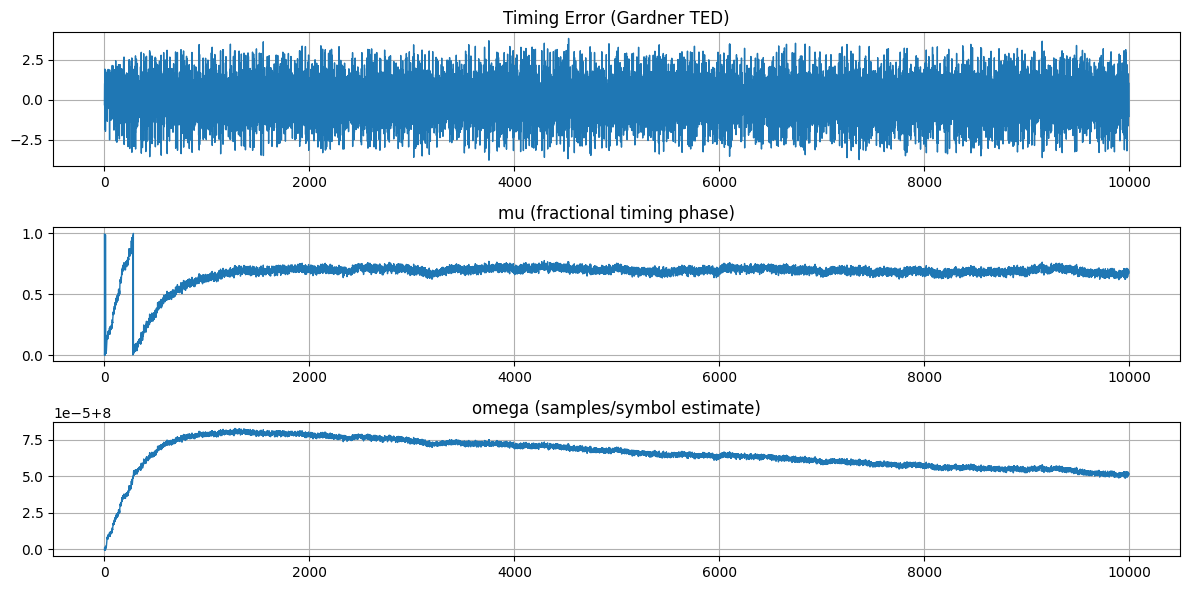

In [29]:
# --- RX: timing recovery (Gardner) -> symbol-rate samples                 ## [RX] 02_Gardner Timing Recovery
def linear_interp(x, t):                                                                  ## Linear Interpolation
    """샘플 인덱스 t(실수)에 대해 선형 보간으로 x[t] 추정"""
    i = int(np.floor(t))
    # print("t:",t); print("i:",t)
    frac = t - i
    # print("frac:",frac)
    if i < 0 or i+1 >= len(x):
        return 0.0 + 0.0j
    return x[i]*(1-frac) + x[i+1]*frac
## if(t==floating point) x[t] can be approximated with linear interpolation.
## In reality, Farrow, cubic can be used for interpolation.

## With the interpolation

# =========================
# 1) 타이밍 복구: Gardner (심볼레이트 샘플 생성)
# =========================
def gardner_timing_recovery(x, sps, mu0=0.0, omega0=None, gain_mu=0.01, gain_omega=1e-5): ##
    """
    x: 매치드필터 출력(샘플레이트)
    sps: nominal samples/symbol
    mu: fractional timing phase (samples)
    omega: samples/symbol 추정
    출력: symbol-rate 샘플 y, timing error e_trace
    """
    if omega0 is None:
        omega = float(sps)
    else:
        omega = float(omega0)

    print("omega0:", omega0); print("sps:", sps); print("omega:", omega)


    mu = float(mu0)  # 0..omega 범위에서 동작(샘플 단위)
    print("mu:", mu); print("mu0:", mu0)

    i = 2*sps  # 앞쪽 여유  ## if(sps==8) i<=16
    y = []
    e_trace = []
    mu_trace = []
    omega_trace = []

    while i + 2*sps < len(x):             ## 16 + 2*8 < 10000
        ## time.sleep(0.1)
        # on-time, early, late (±omega/2)
        x_mid   = linear_interp(x, i + mu)
        x_early = linear_interp(x, i + mu - omega/2)
        x_late  = linear_interp(x, i + mu + omega/2)

        print("mid:   ", i + mu)
        print("early: ", i + mu - omega/2)
        print("late:  ", i + mu + omega/2)


        # Gardner error (복소 입력용: 실수부 취하는 형태가 흔함)
        e = np.real((x_late - x_early) * np.conj(x_mid))
        print("e:", e)

        # 루프 업데이트
        omega = omega + gain_omega * e
        print("omega:", omega)
        mu = mu + omega + gain_mu * e
        print("mu:", mu)

        # 다음 인덱스 이동
        step = int(np.floor(mu))
        print("step:", step)
        mu = mu - step
        i += step
        print("\n")

        y.append(x_mid)
        e_trace.append(e)
        mu_trace.append(mu)
        omega_trace.append(omega)

    return np.array(y), np.array(e_trace), np.array(mu_trace), np.array(omega_trace)


y_sym, e_ted, mu_tr, omega_tr = gardner_timing_recovery(
    rxf, sps=sps, mu0=0.0, gain_mu=0.02, gain_omega=1e-6
)


# =========================
# Visualization
# =========================

# 3) 타이밍 루프 상태/에러
plt.figure(figsize=(12, 6))
plt.subplot(3,1,1)
plt.plot(e_ted, linewidth=1)
plt.title("Timing Error (Gardner TED)")
plt.grid(True)

plt.subplot(3,1,2)
plt.plot(mu_tr, linewidth=1)
plt.title("mu (fractional timing phase)")
plt.grid(True)

plt.subplot(3,1,3)
plt.plot(omega_tr, linewidth=1)
plt.title("omega (samples/symbol estimate)")
plt.grid(True)

plt.tight_layout()
plt.show()


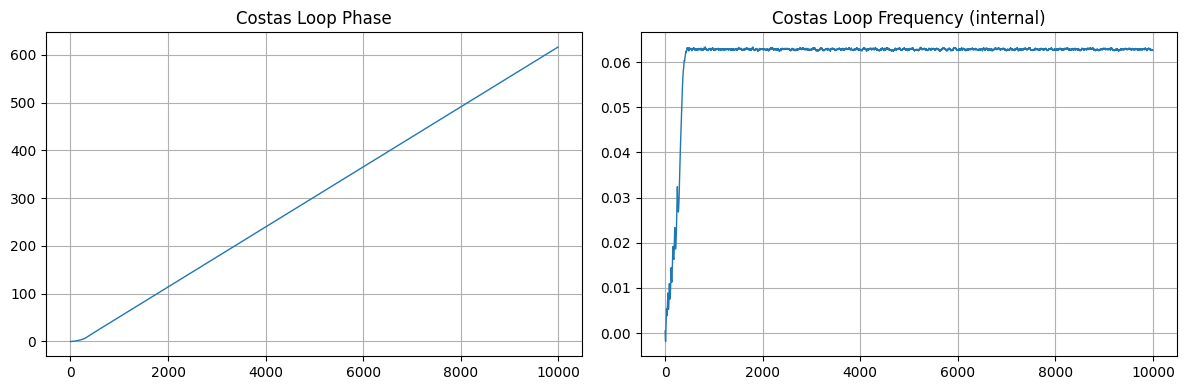

In [30]:
# --- RX: carrier recovery (Costas)

# ==================ㅎ=======
# 2) 캐리어 복구: Costas Loop (QPSK)
# =========================
def costas_loop_qpsk(x, alpha=0.02, beta=0.0004):                         ## [RX] 03_Carrier Recovery
    """
    x: symbol-rate 복소 샘플
    출력: 주파수/위상 보정된 z, phase_trace
    """
    phase = 0.0
    freq = 0.0
    z_out = []
    phase_trace = []
    freq_trace = []

    for xn in x:
        z = xn * np.exp(-1j*phase)

        # QPSK Costas error
        # (하드 제한 기반)
        err = (np.sign(np.real(z)) * np.imag(z)) - (np.sign(np.imag(z)) * np.real(z))

        freq += beta * err
        phase += freq + alpha * err

        z_out.append(z)
        phase_trace.append(phase)
        freq_trace.append(freq)

    return np.array(z_out), np.array(phase_trace), np.array(freq_trace)

y_carr, ph_tr, fr_tr = costas_loop_qpsk(y_sym, alpha=0.03, beta=0.0005)



# =========================
# Visualization
# =========================

# 4) 캐리어 루프(위상/주파수) 트레이스
plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.plot(ph_tr, linewidth=1)
plt.title("Costas Loop Phase")
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(fr_tr, linewidth=1)
plt.title("Costas Loop Frequency (internal)")
plt.grid(True)

plt.tight_layout()
plt.show()


In [31]:
def slicer_qpsk(z):
    """가장 단순 QPSK 하드 슬라이서"""
    I = np.where(np.real(z) >= 0, 1.0, -1.0)
    Q = np.where(np.imag(z) >= 0, 1.0, -1.0)
    return (I + 1j * Q) / np.sqrt(2)

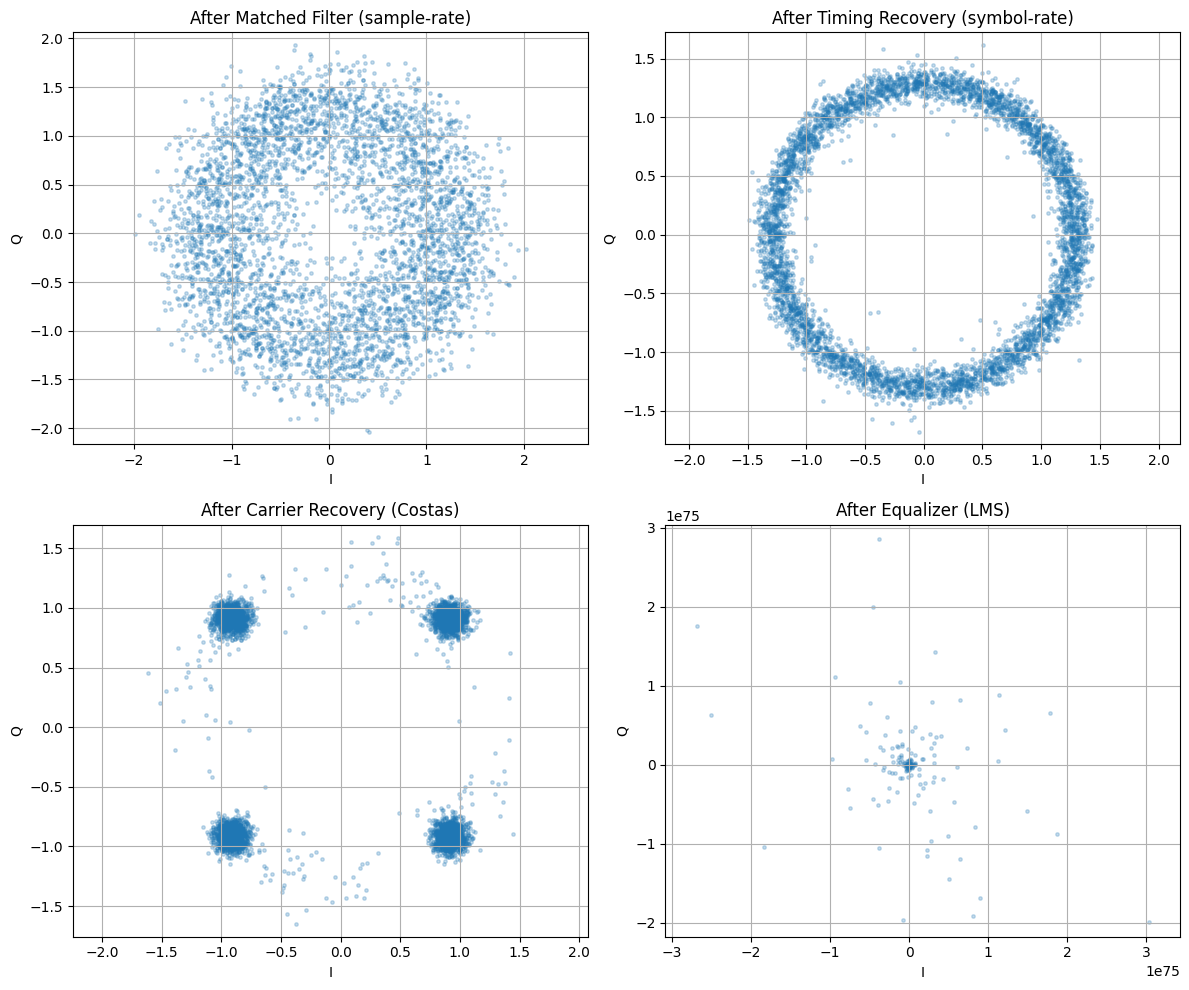

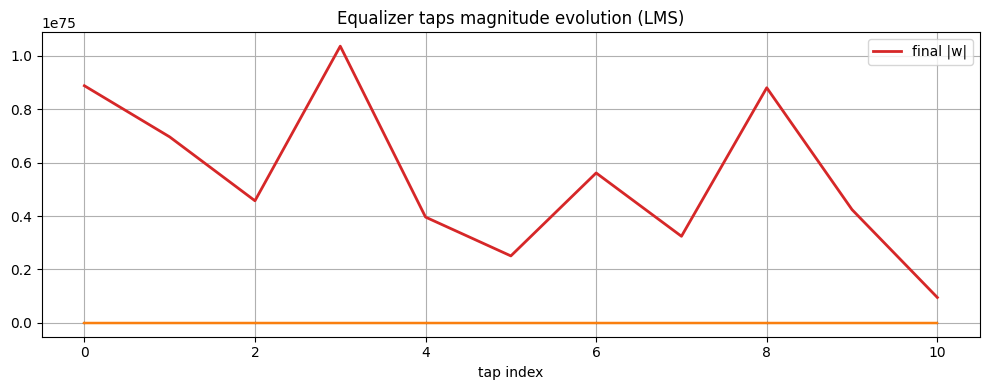

In [32]:
# --- RX: equalization (LMS)
# 훈련 심볼 구간(시뮬레이션이니까 TX 첫 구간을 RX가 안다고 가정)

# =========================
# 3) 등화: 심볼레이트 LMS 선형 등화기
# =========================
def lms_equalizer(x, d_train, ntaps=11, mu=0.01):                         ## [RX] 04_LMS Equalizer
    """
    x: 입력 심볼열(캐리어/타이밍 보정 후)
    d_train: 훈련 심볼(처음 len(d_train)개 구간에서 사용)
    ntaps: 등화기 탭 수(홀수 권장)
    """
    L = ntaps
    w = np.zeros(L, dtype=np.complex128)
    w[L//2] = 1.0 + 0.0j  # 초기 center tap

    y = np.zeros_like(x, dtype=np.complex128)
    e_trace = []
    w_trace = []

    # 버퍼 (최근 샘플이 앞쪽)
    buf = np.zeros(L, dtype=np.complex128)

    for n in range(len(x)):
        buf = np.roll(buf, 1)
        buf[0] = x[n]

        y[n] = np.vdot(w, buf)  # w^H * buf

        # training이면 d_train 사용, 아니면 DD(decision-directed)
        if n < len(d_train):
            d = d_train[n]
        else:
            d = slicer_qpsk(y[n])

        e = d - y[n]
        w = w + mu * e * np.conj(buf)

        if n % 10 == 0:
            w_trace.append(w.copy())
        e_trace.append(e)

    return y, w, np.array(e_trace), np.array(w_trace)

N_train = 400
d_train = syms[:N_train]
y_eq, w_final, e_eq, w_trace = lms_equalizer(y_carr, d_train, ntaps=11, mu=0.01)

# =========================
# Visualization
# =========================
# 2) 컨스텔레이션 변화: (타이밍 전/후/캐리어 후/등화 후)
def scat(ax, z, title):
    step = max(1, len(z)//4000)
    ax.scatter(np.real(z[::step]), np.imag(z[::step]), s=6, alpha=0.25)
    ax.set_title(title)
    ax.grid(True)
    ax.axis("equal")
    ax.set_xlabel("I")
    ax.set_ylabel("Q")

plt.figure(figsize=(12, 10))
ax = plt.subplot(2,2,1); scat(ax, rxf,   "After Matched Filter (sample-rate)")
ax = plt.subplot(2,2,2); scat(ax, y_sym, "After Timing Recovery (symbol-rate)")
ax = plt.subplot(2,2,3); scat(ax, y_carr,"After Carrier Recovery (Costas)")
ax = plt.subplot(2,2,4); scat(ax, y_eq,  "After Equalizer (LMS)")
plt.tight_layout()
plt.show()

# 5) 등화기 탭 변화(크기)
if len(w_trace) > 0:
    plt.figure(figsize=(10,4))
    for k in range(min(30, len(w_trace))):
        plt.plot(np.abs(w_trace[k]), alpha=0.15, color="C1")
    plt.plot(np.abs(w_final), linewidth=2, color="C3", label="final |w|")
    plt.title("Equalizer taps magnitude evolution (LMS)")
    plt.xlabel("tap index")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [33]:
# --- Decisions -> bits
def qpsk_symbols_to_bits(symbols):
    I = np.real(symbols)
    Q = np.imag(symbols)
    b0 = (I < 0).astype(np.int8)
    b1 = (Q < 0).astype(np.int8)
    bits_hat = np.empty(2 * len(symbols), dtype=np.int8)
    bits_hat[0::2] = b0
    bits_hat[1::2] = b1
    return bits_hat

y_dec = slicer_qpsk(y_eq)                                                 ## [RX] 05_Slice_QPSK
bits_hat = qpsk_symbols_to_bits(y_dec)                                    ## [RX] 06_QPSK_Symbols_to_bits

# 길이 맞추기(필터/루프 때문에 초반 일부 손실)
bits_ref = bits[:len(bits_hat)]
ber = np.mean(bits_hat != bits_ref)                                       ## [RX] 07_BER (Bit Error Rate) = Problem / Overall comparison

print(f"BER ≈ {ber:.6e}  (SNR={snr_db} dB, sps={sps}, RRC beta={beta})")


BER ≈ 5.007503e-01  (SNR=14 dB, sps=8, RRC beta=0.35)


In [34]:
# L = 2*sps
# ntr = 200
# starts = np.linspace(0, len(rxf)-L-1, ntr, dtype=int)
# t_eye = np.arange(L)/sps

# print("sps:", sps)
# print("L:", L)
# print("starts:", starts); print("len(starts):", len(starts))
# print("t_eye:", t_eye); print("len(t_eye):", len(t_eye))
